<a href="https://colab.research.google.com/github/DawidSkowronski/PyTorch-Projects/blob/main/DNN_Iris_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification with DNN - Iris dataset

In [138]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import ipywidgets as widgets
from ipywidgets import interact

import numpy as np
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

from sklearn.model_selection import train_test_split

In [4]:
# Loading data
url='https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'

df = pd.read_csv(url)

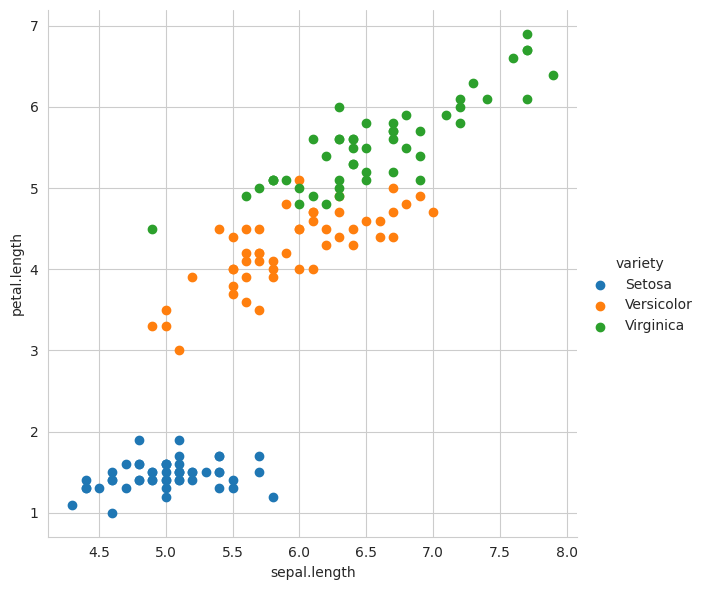

In [5]:
sns.set_style("whitegrid")

# sepal.length, petal.length are iris
# feature data height used to define
# hue store the class of iris dataset.
sns.FacetGrid(df, hue ="variety",
              height = 6).map(plt.scatter,
                              'sepal.length',
                              'petal.length').add_legend()

In [6]:
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [7]:
# Change variety column from str to float
df['variety'] = df['variety'].replace({
    'Setosa': 0,
    'Versicolor': 1,
    'Virginica': 2
}).astype(int)

In [8]:
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [9]:
# Train test Split

X = df.drop('variety', axis=1)
Y = df['variety']

In [54]:
# Train and test set split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,
                                                    train_size=0.6,
                                                    random_state=42)

In [55]:
X_test.index

Index([ 73,  18, 118,  78,  76,  31,  64, 141,  68,  82, 110,  12,  36,   9,
        19,  56, 104,  69,  55, 132,  29, 127,  26, 128, 131, 145, 108, 143,
        45,  30,  22,  15,  65,  11,  42, 146,  51,  27,   4,  32, 142,  85,
        86,  16,  10,  81, 133, 137,  75, 109,  96, 105,  66,   0, 122,  67,
        28,  40,  44,  60],
      dtype='int64')

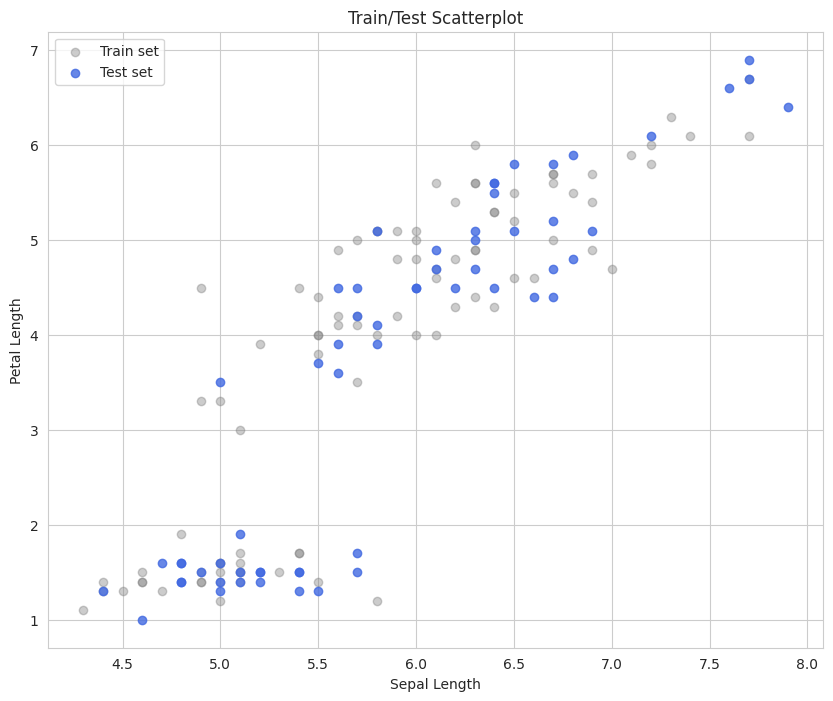

In [56]:
plt.figure(figsize=(10,8))

plt.scatter(X_train.iloc[:,0], X_train.iloc[:,2],
           c='grey',
           marker = 'o',
           label = "Train set",
           alpha = .4)

plt.scatter(X_test.iloc[:,0], X_test.iloc[:,2],
            c='royalblue',
            marker = 'o',
            label = "Test set",
            alpha=.8
            )

plt.title("Train/Test Scatterplot")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend()
plt.show()

In [57]:
# Convert DataFrames to numpy arrays, then to tensors
# X features to float tensors
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)

# Y labels to tensors long (int)
Y_train_tensor = torch.LongTensor(Y_train.values)
Y_test_tensor = torch.LongTensor(Y_test.values)

# Creating the DNN model

In [58]:
# Model Class that inherits from nn.Module

class Model(nn.Module):
  # Input layer (4 characteristics of iris flower)
  # Hidden layer
  # Output layer (3 species of iris)

  # Number of neurons in each layer
  def __init__(self, input_number = 4,
               hidden1_number = 8,
               hidden2_number = 4,
               output_number = 3):
    super().__init__() # initiate nn.Module

  # fc - fully connected
    self.fc1 = nn.Linear(input_number, hidden1_number)
    self.fc2 = nn.Linear(hidden1_number, hidden2_number)
    self.out = nn.Linear(hidden2_number, output_number)

  # Forward propagation
  def forward(self, X):
    # Move data through layers
    X = F.relu(self.fc1(X))
    X = F.relu(self.fc2(X))
    X = self.out(X)

    return X




In [77]:
# Set seed for repeatability
torch.manual_seed(42)

# Create instance of Model
model = Model()

In [78]:
# Criterion for model to measure prediction error
criterion = nn.CrossEntropyLoss()

# Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)


In [79]:
# Epochs
epochs = 200

losses = []

for epoch in range(epochs):
  Y_predict = model.forward(X_train_tensor) # Get predicted results

  # Measure the error
  loss = criterion(Y_predict, Y_train_tensor)

  # History of losses
  losses.append(loss.detach().numpy())
  # The expression .detach().numpy() is used in PyTorch when converting a torch

  # Print progress
  if epoch % 10 ==0:
    print(f"Epoch: {epoch}, loss: {loss}")

  # Back propagation

  optimizer.zero_grad() # Clears the old gradient values
  loss.backward()
  # Performs backpropagation to calculate the new gradients of the loss
  # with respect to each parameter (weights)
  optimizer.step()
  # Uses the calculated gradients to update the model's parameters

Epoch: 0, loss: 1.3478267192840576
Epoch: 10, loss: 1.0763174295425415
Epoch: 20, loss: 1.0175174474716187
Epoch: 30, loss: 0.918058454990387
Epoch: 40, loss: 0.8224446773529053
Epoch: 50, loss: 0.7486101984977722
Epoch: 60, loss: 0.6988057494163513
Epoch: 70, loss: 0.6579790711402893
Epoch: 80, loss: 0.5547263622283936
Epoch: 90, loss: 0.45052769780158997
Epoch: 100, loss: 0.35872581601142883
Epoch: 110, loss: 0.24459291994571686
Epoch: 120, loss: 0.14720891416072845
Epoch: 130, loss: 0.09904374182224274
Epoch: 140, loss: 0.07956444472074509
Epoch: 150, loss: 0.07053831219673157
Epoch: 160, loss: 0.06574102491140366
Epoch: 170, loss: 0.06276722252368927
Epoch: 180, loss: 0.06066500395536423
Epoch: 190, loss: 0.05901841074228287


Text(0.5, 0, 'Epoch')

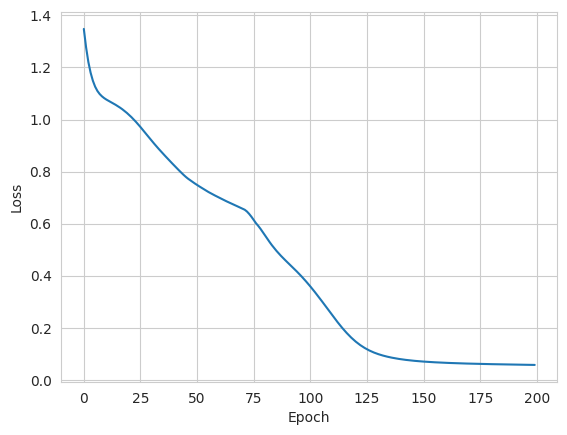

In [80]:
# Loss history plot

plt.plot(range(epochs), losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")

# Model evaluation

In [81]:
# Validate the model on Test Data Set

# Send test data thru model, without changing parameters
with torch.no_grad(): # Trun off back propagation
  Y_eval = model.forward(X_test_tensor)
  loss = criterion(Y_eval, Y_test_tensor)


In [82]:
loss

tensor(0.0467)

In [83]:
correct = 0
Y_predict_test = []

with torch.no_grad():
  for i, data in enumerate(X_test_tensor):
    Y_value = model.forward(data)
    predicted_class = Y_value.argmax().item()

    Y_predict_test.append(predicted_class)

    # What species of iris was pointed by the model
    print(f"({i+1}.) {str(Y_value)} \t {Y_test_tensor[i]} \t {Y_value.argmax().item()}")

    # Check if the model prediction is correct
    if predicted_class == Y_test_tensor[i].item():
      correct += 1

print()
print(f"{correct} correct predictions out of all {len(Y_test)} test observations")

Y_predict_test = np.array(Y_predict_test)

(1.) tensor([-1.9190,  8.7165,  2.3808]) 	 1 	 1
(2.) tensor([ 15.8788,   8.5005, -23.1782]) 	 0 	 0
(3.) tensor([-17.3613,   8.7261,  24.6930]) 	 2 	 2
(4.) tensor([-3.0586,  8.5257,  4.0394]) 	 1 	 1
(5.) tensor([-2.6670,  9.1912,  3.4256]) 	 1 	 1
(6.) tensor([ 14.9022,   7.9357, -21.7351]) 	 0 	 0
(7.) tensor([ 1.4739,  8.1471, -2.4544]) 	 1 	 1
(8.) tensor([-9.3120,  8.7945, 13.0545]) 	 2 	 2
(9.) tensor([-5.1984,  7.9018,  7.1776]) 	 1 	 1
(10.) tensor([ 0.5768,  8.2290, -1.1711]) 	 1 	 1
(11.) tensor([-7.4164,  8.8005, 10.3153]) 	 2 	 2
(12.) tensor([ 13.8992,   7.1821, -20.2408]) 	 0 	 0
(13.) tensor([ 15.4705,   8.0162, -22.5574]) 	 0 	 0
(14.) tensor([ 14.1858,   7.3343, -20.6634]) 	 0 	 0
(15.) tensor([ 14.9419,   7.9455, -21.7929]) 	 0 	 0
(16.) tensor([-2.7515,  9.1466,  3.5498]) 	 1 	 1
(17.) tensor([-12.5816,   8.2775,  17.8171]) 	 2 	 2
(18.) tensor([ 0.2956,  7.9392, -0.7466]) 	 1 	 1
(19.) tensor([-2.4357,  8.3059,  3.1558]) 	 1 	 1
(20.) tensor([-12.5910,   7.9865,  

In [84]:
# Accuracy
# FP, TP, FN, TN
# specificity,

In [85]:
# Evaluating New Data
iris_new = torch.tensor([4.6, 3.2, 1.4, 0.8])

In [86]:
with torch.no_grad():
  print(model(iris_new))
  print(model(iris_new).argmax())

tensor([ 12.1040,   7.1549, -17.6594])
tensor(0)


In [87]:
iris_new_2 = torch.tensor([6.2,	3.4,	5.4,	2.3])

In [88]:
with torch.no_grad():
  print(model(iris_new_2))
  print(model(iris_new_2).argmax())

tensor([-10.6773,   8.4407,  15.0526])
tensor(2)


# Save DNN model

In [89]:
# Save
torch.save(model.state_dict(), 'iris_DNN_model.pt')

In [90]:
# Load
new_model = Model()
new_model.load_state_dict(torch.load('iris_DNN_model.pt'))

<All keys matched successfully>

In [91]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=4, bias=True)
  (out): Linear(in_features=4, out_features=3, bias=True)
)

# Scatterplot with predictions

In [136]:
# New point
with torch.no_grad():
  odd_iris = torch.tensor([5. ,20. ,5. ,5.])
  new_point_pred = model(odd_iris).argmax()
print(new_point_pred)

tensor(1)


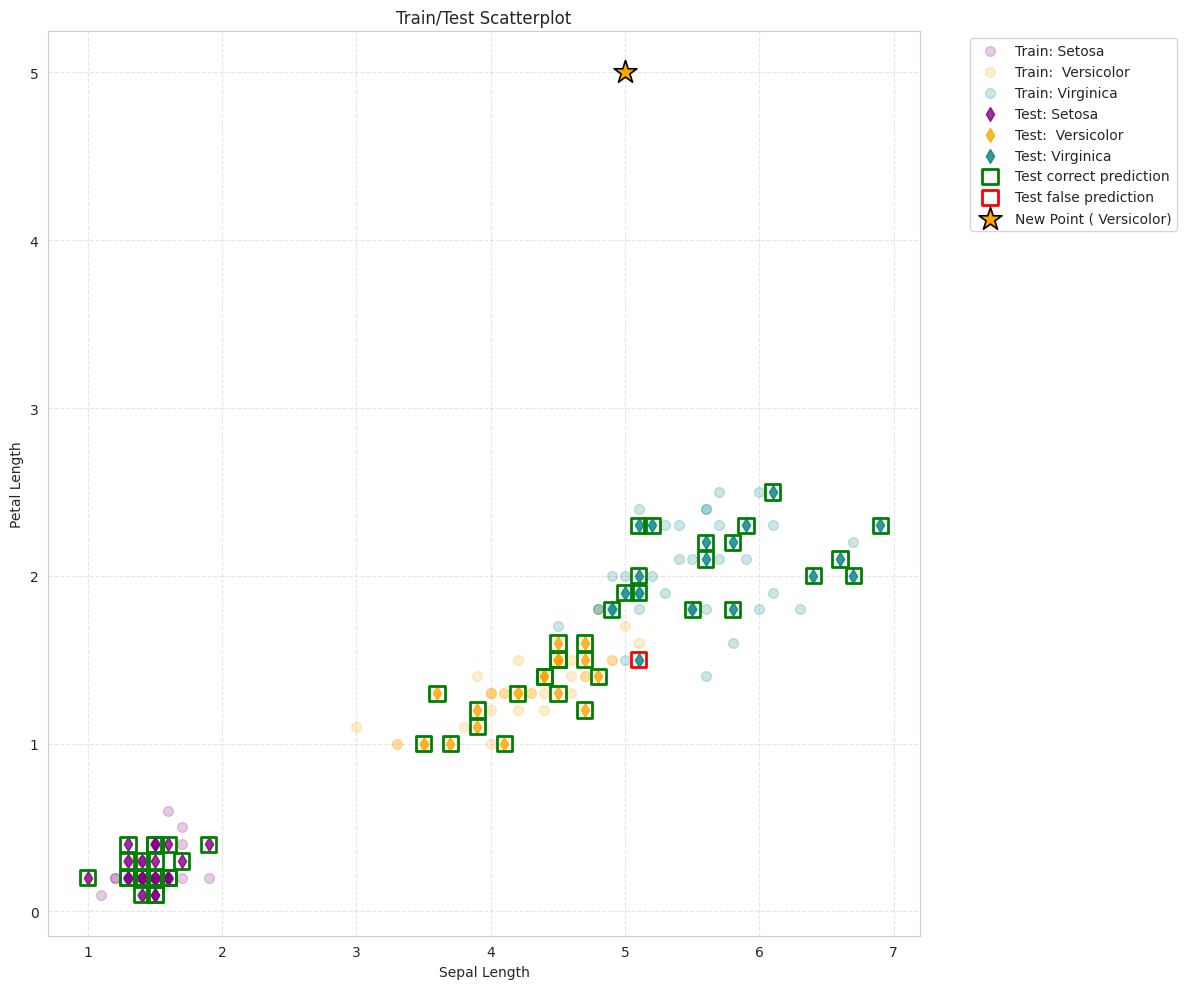

In [137]:
plt.figure(figsize=(12,10))

first_axis_feature = 0
second_axis_fature = 1

colors = {0: "purple",
          1: "orange",
          2: 'teal'}
species_names = {0: 'Setosa',
                 1: ' Versicolor',
                 2: 'Virginica'}

# Iterate through species
# Train set

alpha_train = .2
for species_val, color in colors.items():
  mask_train = (Y_train == species_val).values
  plt.scatter(X_train.iloc[mask_train, first_axis_feature], X_train.iloc[mask_train, second_axis_fature],
              c = color, marker = 'o', alpha = alpha_train,
              s= 50, label = f"Train: {species_names[species_val]}")

# Test set
alpha_test = .8
for species_val, color in colors.items():
  mask_test = (Y_test == species_val).values
  plt.scatter(X_test.iloc[mask_test, first_axis_feature], X_test.iloc[mask_test,second_axis_fature],
              c = color, marker = 'd', alpha = alpha_test,
              s = 50, label = f"Test: {species_names[species_val]}")


correct_mask = (Y_test.values == Y_predict_test)
incorrect_mask = (Y_test.values != Y_predict_test)

plt.scatter(X_test.iloc[correct_mask, first_axis_feature], X_test.iloc[correct_mask, second_axis_fature],
            facecolors = 'none',
            edgecolors = 'green',
            marker = 's',
            s = 120,
            linewidth = 2,
            label = "Test correct prediction")

plt.scatter(X_test.iloc[incorrect_mask, first_axis_feature], X_test.iloc[incorrect_mask, second_axis_fature],
            facecolors = 'none',
            edgecolors = 'red',
            marker = 's',
            s = 120,
            linewidth = 2,
            label = "Test false prediction")

# New point
plt.scatter(odd_iris[first_axis_feature],
            odd_iris[second_axis_fature],
            color = colors[new_point_pred.item()],
            marker = '*',
            s = 300,
            edgecolors = 'black',
            linewidth = 1.2,
            label = f"New Point ({species_names[new_point_pred.item()]})")

plt.title("Train/Test Scatterplot")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()


plt.show()

In [157]:

# Dictionaries
colors = {0: "purple", 1: "orange", 2: 'teal'}
species_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}

correct_mask = (Y_test.values == Y_predict_test)
incorrect_mask = (Y_test.values != Y_predict_test)

# New Point
with torch.no_grad():
    odd_iris = torch.tensor([1., 4., 6., 1.])
    new_point_pred = model(odd_iris).argmax()

feature_dict = {
    'Sepal Length': 0,
    'Sepal Width': 1,
    'Petal Length': 2,
    'Petal Width': 3
}


# Interactive Plot
@interact(
    x_feat=widgets.Dropdown(options=feature_dict, value=0, description='Oś X:'),
    y_feat=widgets.Dropdown(options=feature_dict, value=1, description='Oś Y:')
)
def plot_interactive_iris(x_feat, y_feat):
    if x_feat == y_feat:
        print("Axis must contain different features!")
        return

    plt.figure(figsize=(10, 8))

    # --- Training Set  ---
    alpha_train = .2
    for species_val, color in colors.items():
        mask_train = (Y_train == species_val).values
        plt.scatter(X_train.iloc[mask_train, x_feat], X_train.iloc[mask_train, y_feat],
                    c=color, marker='o', alpha=alpha_train, s=50,
                    label=f"Train: {species_names[species_val]}")

    # --- Test Set ---
    alpha_test = .8
    for species_val, color in colors.items():
        mask_test = (Y_test == species_val).values
        plt.scatter(X_test.iloc[mask_test, x_feat], X_test.iloc[mask_test, y_feat],
                    c=color, marker='d', alpha=alpha_test, s=50,
                    label=f"Test: {species_names[species_val]}")

    # --- Prediction ---
    plt.scatter(X_test.iloc[correct_mask, x_feat], X_test.iloc[correct_mask, y_feat],
                facecolors='none', edgecolors='green', marker='s', s=120, linewidth=2,
                label="Test: correct prediction")

    plt.scatter(X_test.iloc[incorrect_mask, x_feat], X_test.iloc[incorrect_mask, y_feat],
                facecolors='none', edgecolors='red', marker='s', s=120, linewidth=2,
                label="Test: false prediction")

    # --- New Point ---
    plt.scatter(odd_iris[x_feat].item(), odd_iris[y_feat].item(),
                color=colors[new_point_pred.item()], marker='*', s=400,
                edgecolors='black', linewidth=1.5,
                label=f"New Point ({species_names[new_point_pred.item()]})")

    # --- Plot Settings ---
    inv_feature_dict = {v: k for k, v in feature_dict.items()}

    plt.title(f"Features: {inv_feature_dict[x_feat]} vs {inv_feature_dict[y_feat]}", fontsize=14)
    plt.xlabel(inv_feature_dict[x_feat], fontsize=12)
    plt.ylabel(inv_feature_dict[y_feat], fontsize=12)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Oś X:', options={'Sepal Length': 0, 'Sepal Width': 1, 'Petal Lengt…